In [79]:
df.to_csv(
    "cleaned_retail.csv",
    index=False
)

In [80]:
rfm.to_csv(
    "rfm_table.csv"
)

In [85]:
#aggregate daily sales
daily_sales = (
    df.groupby(
        df['InvoiceDate'].dt.date
    )['TotalAmount']
    .sum()
    .reset_index()
)
daily_sales.head()

,InvoiceDate,TotalAmount
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [87]:
daily_sales.columns = [
    'ds',
    'y'
]
daily_sales.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [88]:
!pip install prophet

In [104]:
daily_sales = (
    df.groupby(
        df['InvoiceDate'].dt.date
    )['TotalAmount']
    .sum()
    .reset_index()
)

daily_sales.columns = [
    'SalesDate',
    'DailySales'
]

daily_sales.head()

,SalesDate,DailySales
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [105]:
prophet_data = daily_sales.rename(
    columns={
        'SalesDate':'ds',
        'DailySales':'y'
    }
)

In [107]:
#Demand Forecasting using Prophet Model
from prophet import Prophet

model = Prophet()
model.fit(prophet_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [109]:
forecast_readable = forecast.rename( columns={ 'ds':'SalesDate', 'yhat':'PredictedSales', 'yhat_lower':'MinPredictedSales', 'yhat_upper':'MaxPredictedSales' } )

In [110]:
forecast_readable[
[
'SalesDate',
'PredictedSales',
'MinPredictedSales',
'MaxPredictedSales'
]
].tail()

,SalesDate,PredictedSales,MinPredictedSales,MaxPredictedSales
330,2012-01-04,56838.795122,38111.794038,74495.972062
331,2012-01-05,64292.078034,46430.634820,81852.186166
332,2012-01-06,56504.425108,37681.168835,74251.178578
333,2012-01-07,68529.995308,51921.268966,87039.359565
334,2012-01-08,43340.640553,25944.497860,61201.169847


In [111]:
#Giving Time period
future = model.make_future_dataframe(
    periods=30
)
future.tail()

,ds
330,2012-01-04
331,2012-01-05
332,2012-01-06
333,2012-01-07
334,2012-01-08


In [112]:
#Forecast
forecast = model.predict(
    future
)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-12-01,25315.190305,7985.158344,43328.243549,25315.190305,25315.190305,-694.071936,-694.071936,-694.071936,-694.071936,-694.071936,-694.071936,0.0,0.0,0.0,24621.118370
1,2010-12-02,25303.109664,14123.041583,50470.085697,25303.109664,25303.109664,6565.318297,6565.318297,6565.318297,6565.318297,6565.318297,6565.318297,0.0,0.0,0.0,31868.427961
2,2010-12-03,25291.029022,4547.128580,42016.140913,25291.029022,25291.029022,-1416.227308,-1416.227308,-1416.227308,-1416.227308,-1416.227308,-1416.227308,0.0,0.0,0.0,23874.801715
3,2010-12-05,25266.867739,-7110.805572,27688.699606,25266.867739,25266.867739,-14967.797220,-14967.797220,-14967.797220,-14967.797220,-14967.797220,-14967.797220,0.0,0.0,0.0,10299.070518
4,2010-12-06,25254.787097,4949.246921,40566.942685,25254.787097,25254.787097,-1939.068154,-1939.068154,-1939.068154,-1939.068154,-1939.068154,-1939.068154,0.0,0.0,0.0,23315.718943


In [113]:
#Prediction
forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
].tail()

,ds,yhat,yhat_lower,yhat_upper
330,2012-01-04,56838.795122,40245.029370,74065.540706
331,2012-01-05,64292.078034,47009.841617,81633.624419
332,2012-01-06,56504.425108,39767.464058,74060.251257
333,2012-01-07,68529.995308,50235.153657,86678.056739
334,2012-01-08,43340.640553,24160.614614,61407.269464


In [ ]:
del model

In [115]:
forecast_readable.to_csv(
    "sales_forecast.csv",
    index=False
)

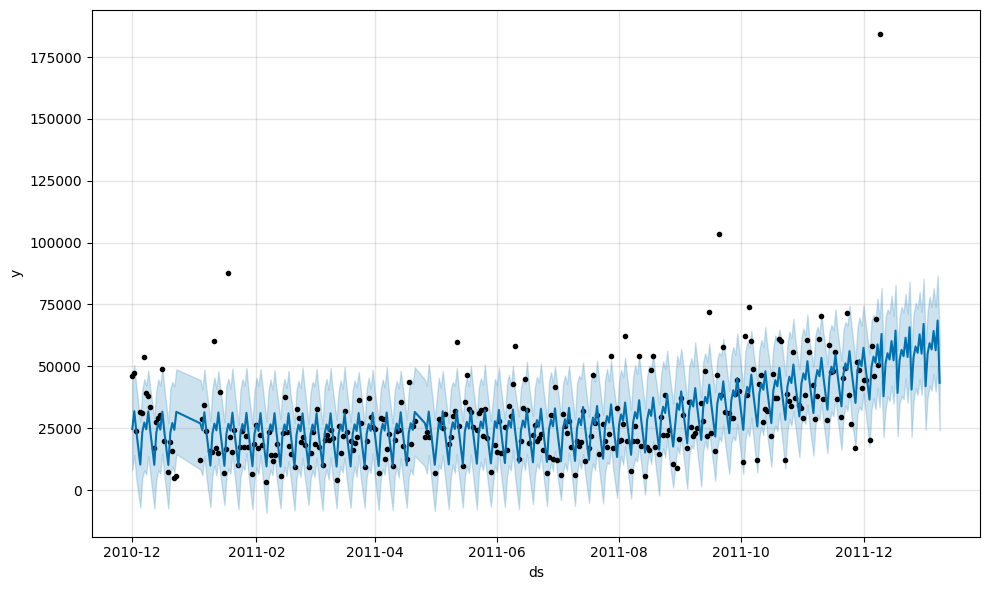

In [120]:
#Forecast
fig = model.plot(
    forecast
)
plt.savefig(
    "forecast_chart.png",
    dpi=300
)

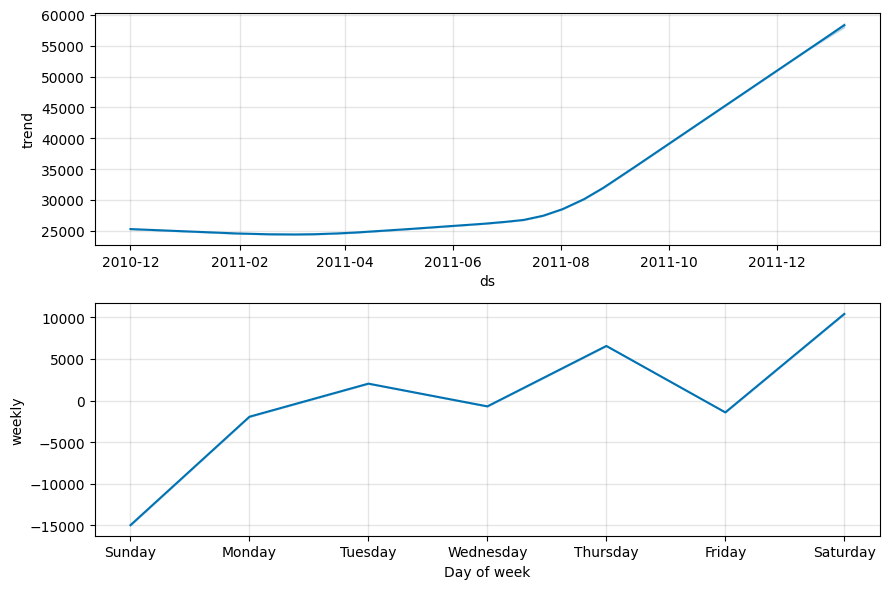

In [118]:
#Trend & Seasonality
fig2 = model.plot_components(
    forecast
)
plt.savefig(
    "forecast_components.png",
    dpi=300
)

In [121]:
#export csv
forecast.to_csv(
    "sales_forecast.csv",
    index=False
)

(305, 2)


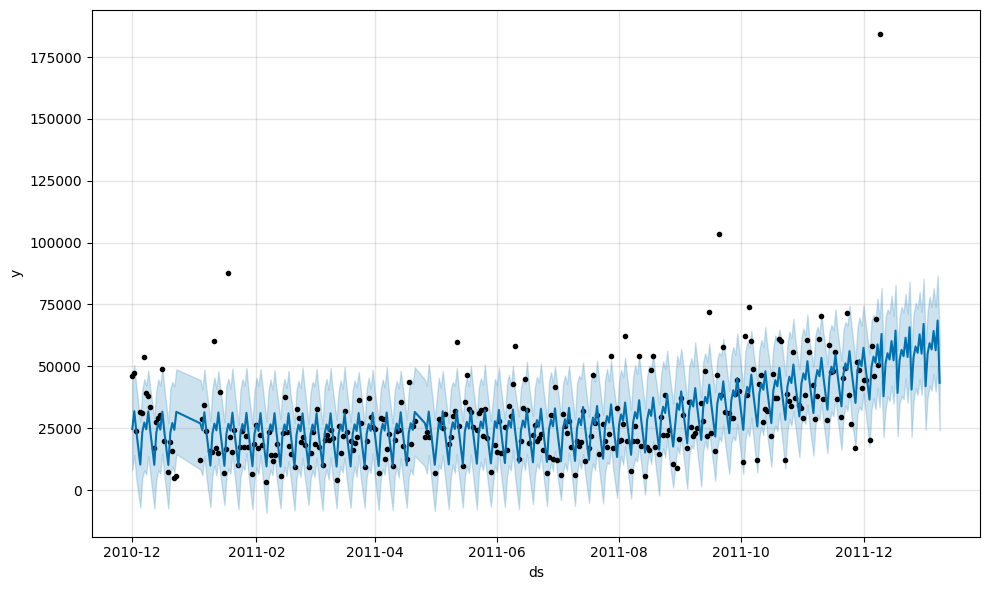

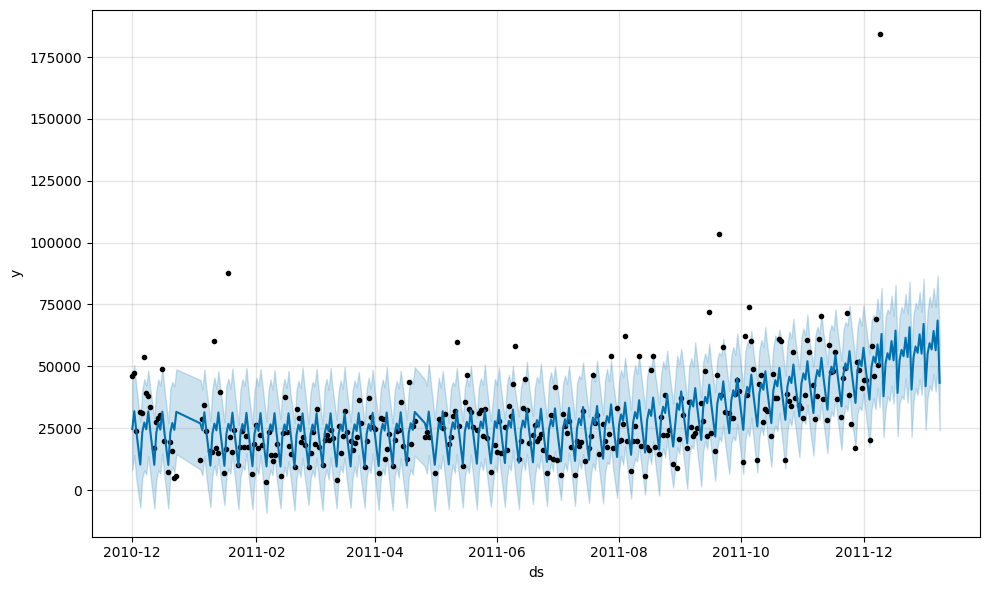

In [122]:
print(daily_sales.shape)

forecast[
['ds','yhat']
].tail()
model.plot(forecast)